In [75]:
!pip install pandas
!pip install missingno

In [76]:
import pandas as pd
import numpy as np
import missingno
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
nykaa = pd.read_csv("data/nykaa_campaign_data.csv")
nykaa.head(10)


,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,06-04-2025
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,14-01-2025
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,04-06-2025
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024
5,NY-CMP-1005,Influencer,Youth,26,"Email, Instagram",83919,7497,2061,1555,877020,137.79,3.09,Hindi,13.24,Premium Shoppers,23-09-2024
6,NY-CMP-1006,Paid Ads,College Students,21,"YouTube, Google, WhatsApp",82267,5534,1873,1386,633402,210.17,1.17,Tamil,10.69,Youth,01-09-2024
7,NY-CMP-1007,Social Media,Working Women,6,"Instagram, WhatsApp, Google",32482,2665,1488,925,326525,147.29,1.40,Hindi,15.63,Tier 2 City Customers,31-05-2025
8,NY-CMP-1008,Influencer,Premium Shoppers,27,"Facebook, WhatsApp, Email",73813,8680,5031,2551,1058665,87.74,3.73,Hindi,22.03,Tier 2 City Customers,24-03-2025
9,NY-CMP-1009,Social Media,College Students,11,Email,88895,6284,1600,858,603174,269.82,1.61,Hindi,9.83,Youth,29-04-2025


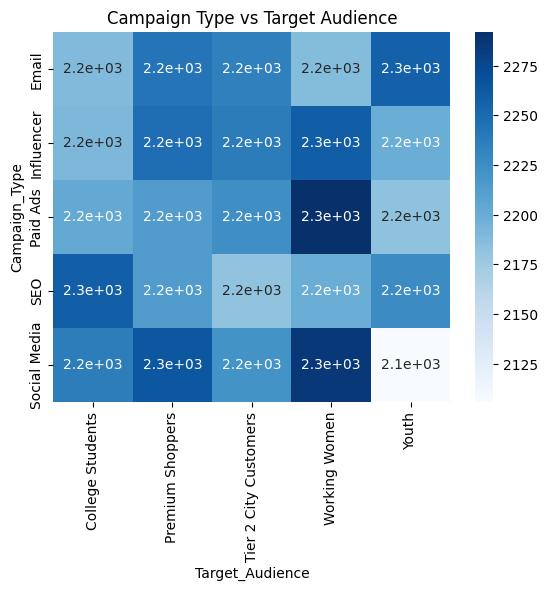

In [78]:
ct = pd.crosstab(nykaa['Campaign_Type'], nykaa['Target_Audience'])

sns.heatmap(ct, annot=True, cmap='Blues')
plt.title("Campaign Type vs Target Audience")
plt.show()

In [79]:
nykaa.shape

(55555, 16)

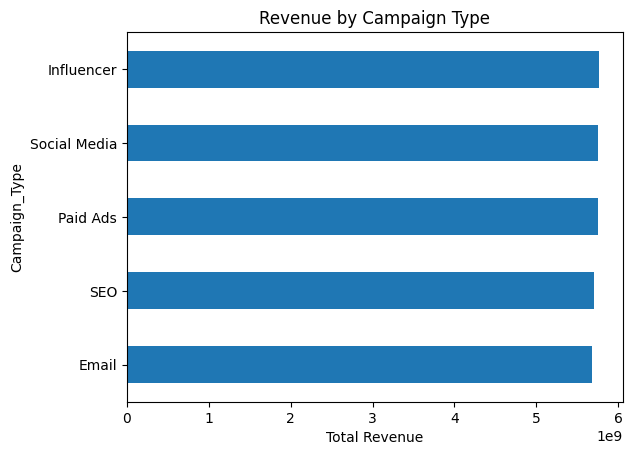

In [80]:
nykaa.groupby('Campaign_Type')['Revenue'].sum().sort_values().plot(kind='barh')

plt.xlabel("Total Revenue")
plt.title("Revenue by Campaign Type")
plt.show()

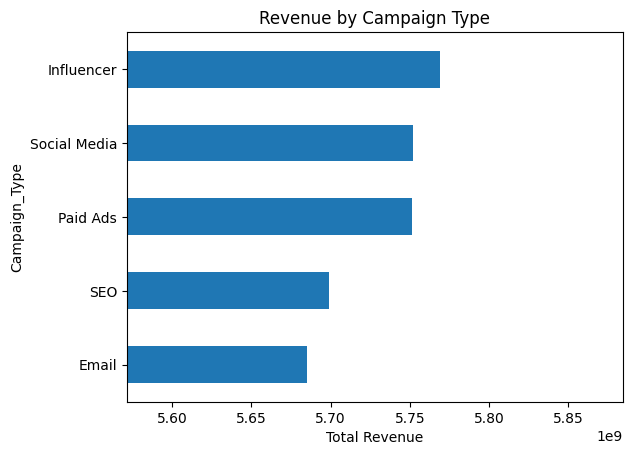

In [81]:
rev = nykaa.groupby('Campaign_Type')['Revenue'].sum().sort_values()

ax = rev.plot(kind='barh')

plt.xlim(rev.min()*0.98, rev.max()*1.02)

plt.xlabel("Total Revenue")
plt.title("Revenue by Campaign Type")
plt.show()

In [82]:
nykaa.dtypes

Campaign_ID             str
Campaign_Type           str
Target_Audience         str
Duration              int64
Channel_Used            str
Impressions           int64
Clicks                int64
Leads                 int64
Conversions           int64
Revenue               int64
Acquisition_Cost    float64
ROI                 float64
Language                str
Engagement_Score    float64
Customer_Segment        str
Date                    str
dtype: object

In [83]:
nykaa.isnull().sum()
# no missing values?

Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [84]:
nykaa.describe()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,55555.000000,55555.000000,55555.000000,55555.000000,55555.000000,5.555500e+04,55555.000000,55555.000000,55555.000000
mean,17.446044,55087.885357,4688.070507,1877.271119,1032.866925,5.158197e+05,377.347068,2.713807,13.784169
std,7.520438,25930.001514,3178.686285,1435.636117,862.496788,4.900121e+05,541.084524,4.493380,6.353125
min,5.000000,10001.000000,202.000000,56.000000,19.000000,6.183000e+03,9.080000,-0.970000,2.600000
25%,11.000000,32680.000000,2110.000000,779.000000,400.000000,1.777060e+05,105.435000,0.040000,8.360000
50%,17.000000,55182.000000,3907.000000,1481.000000,779.000000,3.604360e+05,207.510000,1.240000,13.600000
75%,24.000000,77514.500000,6688.000000,2605.000000,1414.000000,6.874225e+05,428.580000,3.630000,18.855000
max,30.000000,100000.000000,14868.000000,8876.000000,6686.000000,4.579910e+06,15473.160000,74.420000,30.910000


In [85]:
nykaa['Duration'].describe()

count    55555.000000
mean        17.446044
std          7.520438
min          5.000000
25%         11.000000
50%         17.000000
75%         24.000000
max         30.000000
Name: Duration, dtype: float64

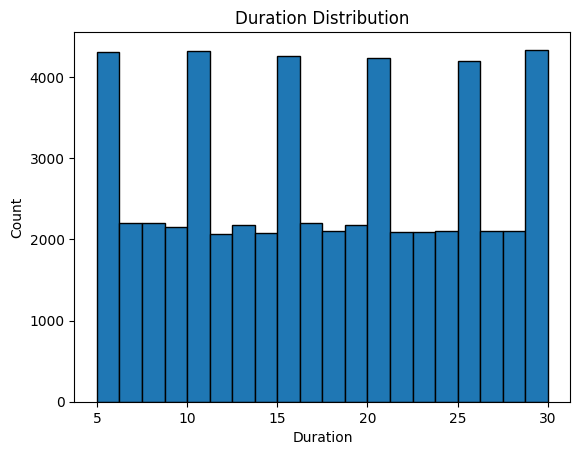

In [86]:
plt.hist(nykaa['Duration'], bins=20, edgecolor='black')
plt.title("Duration Distribution")
plt.xlabel("Duration")
plt.ylabel('Count')
plt.show()

<Axes: xlabel='Duration', ylabel='Count'>

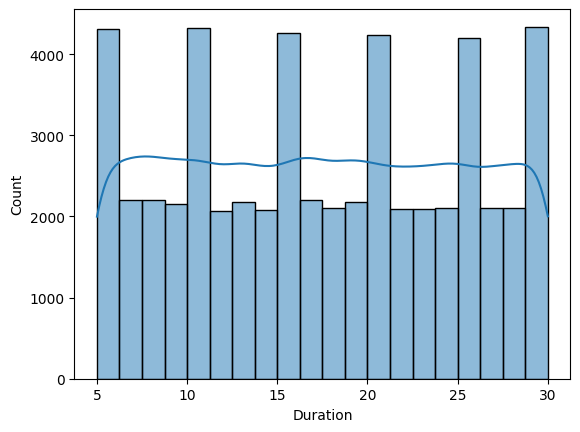

In [87]:
sns.histplot(nykaa["Duration"], bins=20, kde = True)

<Axes: xlabel='Duration'>

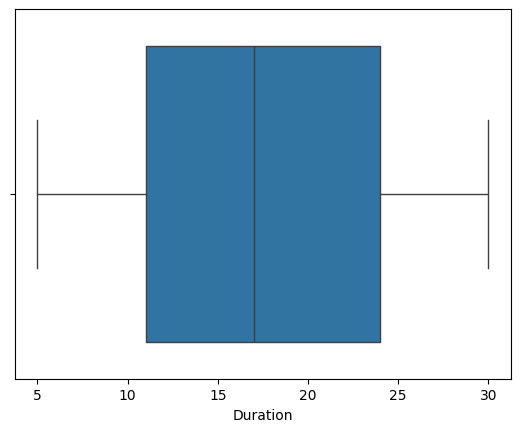

In [88]:
sns.boxplot(x = nykaa["Duration"])

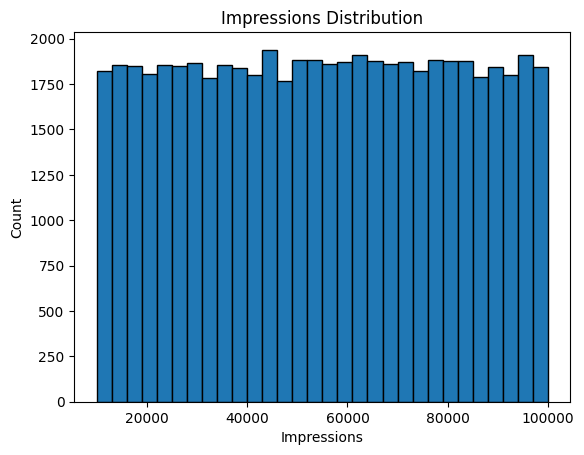

In [89]:
plt.hist(nykaa['Impressions'], bins = 30, edgecolor = "black")
plt.xlabel("Impressions")
plt.ylabel("Count")
plt.title("Impressions Distribution")
plt.show()

In [90]:
cols = ["Clicks",	"Leads"	,"Conversions", 	"Revenue",	"Acquisition_Cost",	"ROI", "Engagement_Score"]

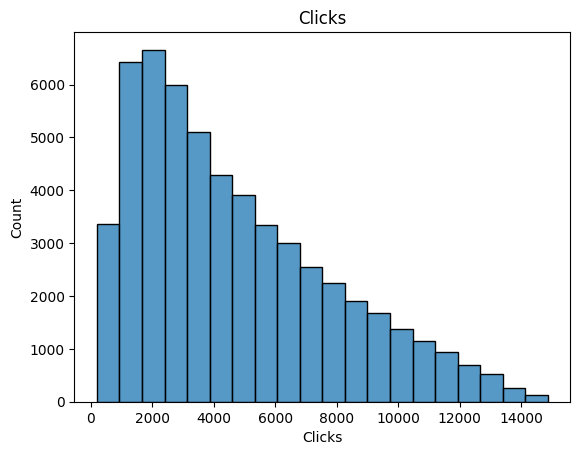

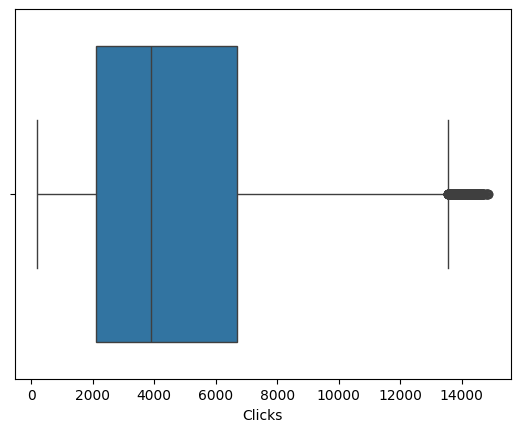

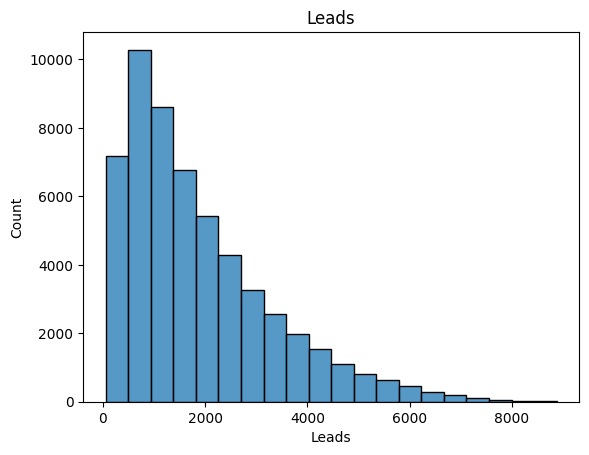

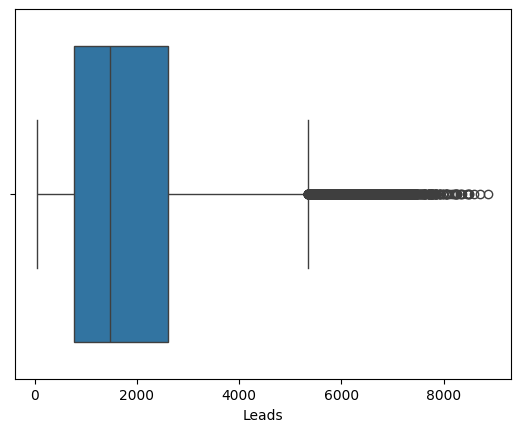

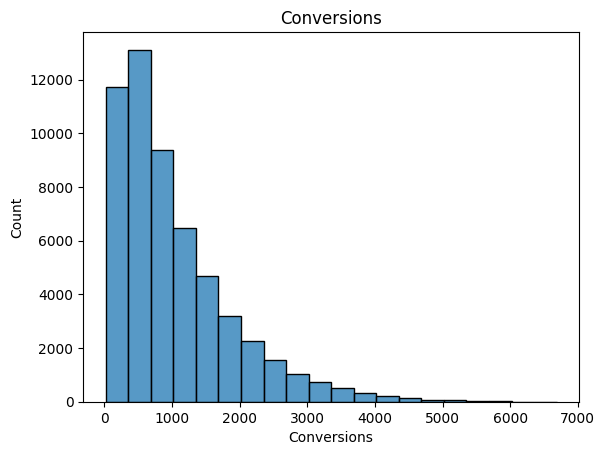

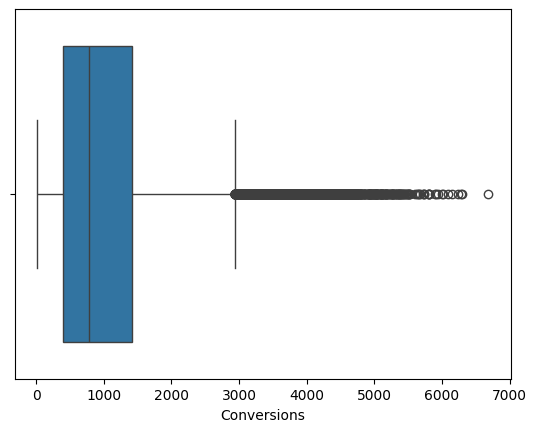

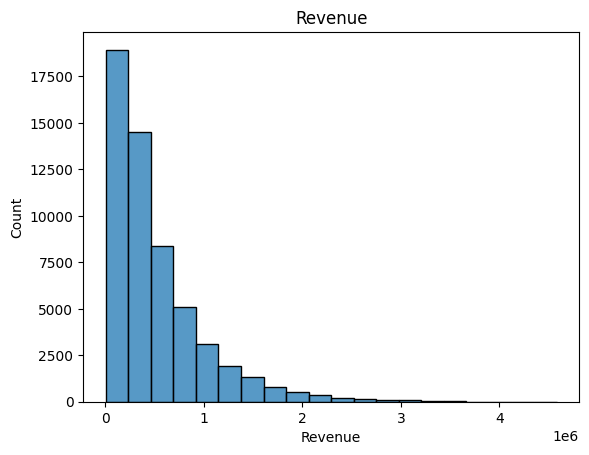

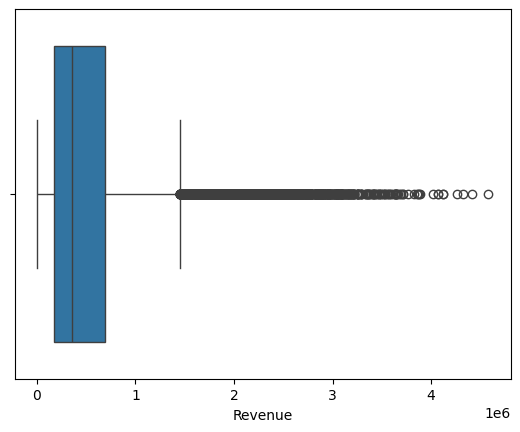

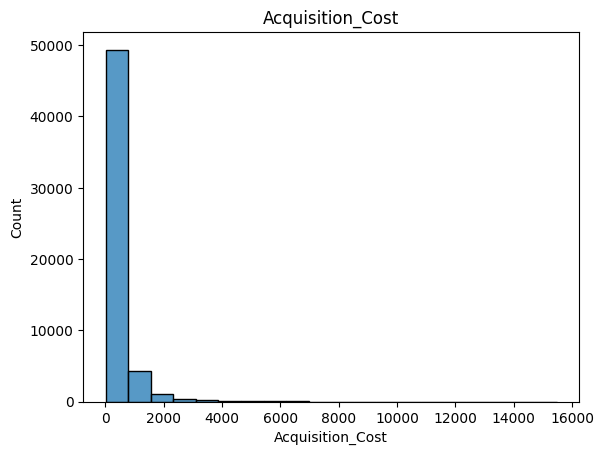

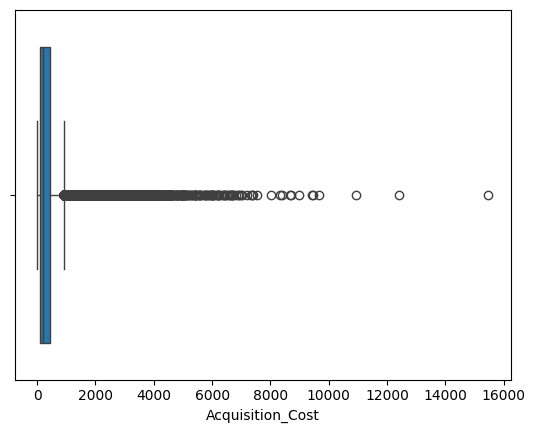

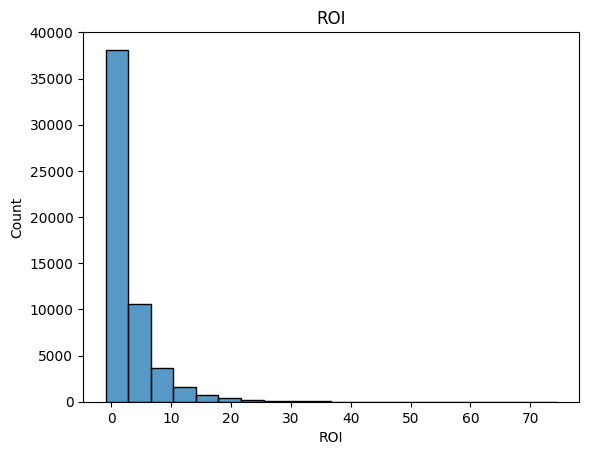

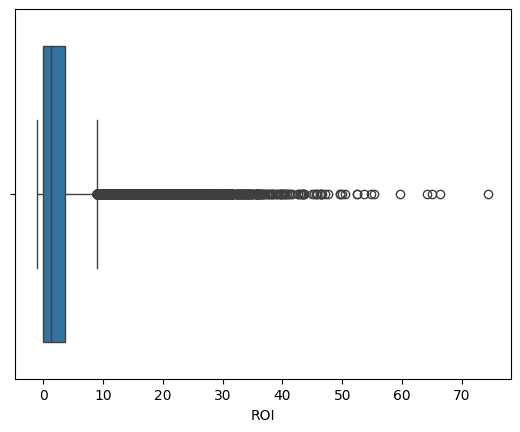

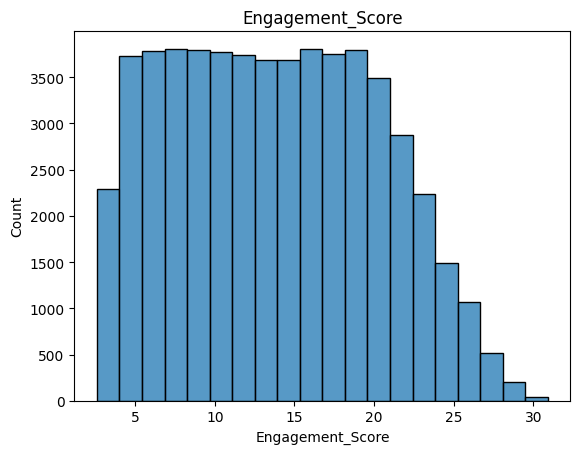

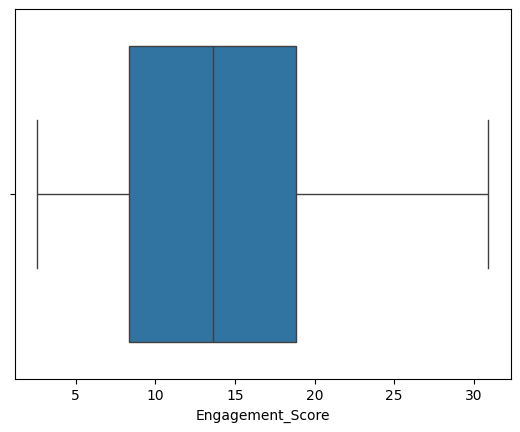

In [91]:
for col in cols:
  sns.histplot(nykaa[col], bins=20)
  plt.title(col)
  plt.show()

  sns.boxplot(x = nykaa[col])
  plt.show()

In [92]:
cols_cat = ["Campaign_Type",	"Target_Audience", "Target_Audience", "Channel_Used", "Language",	"Customer_Segment"]

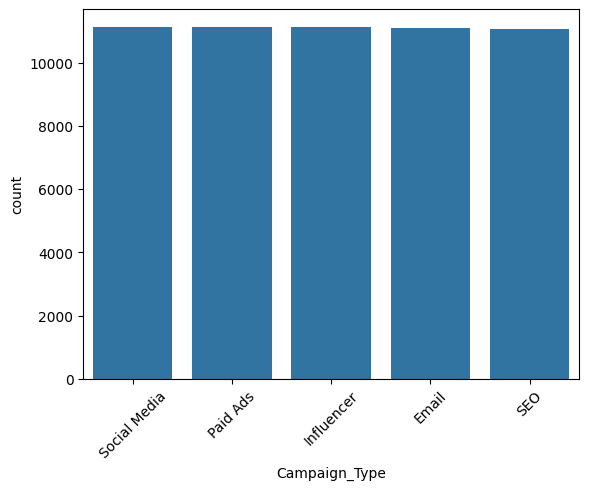

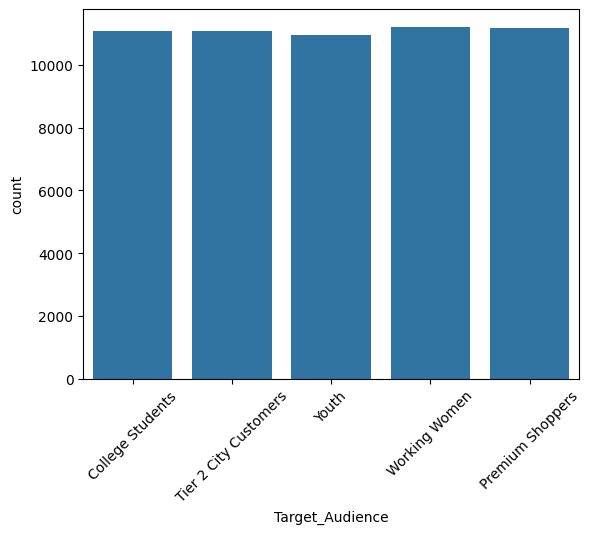

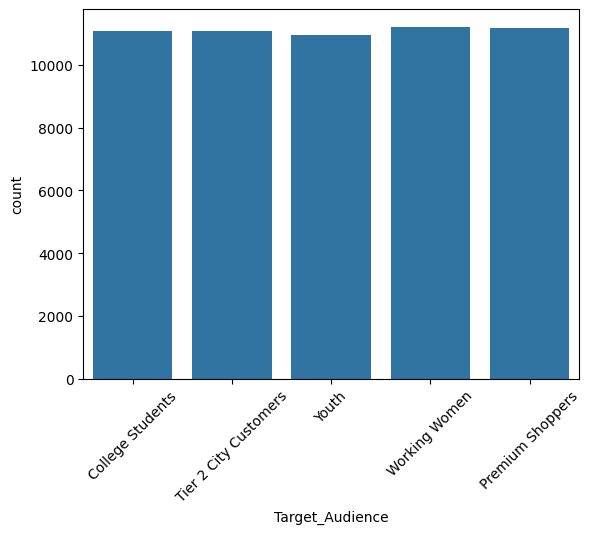

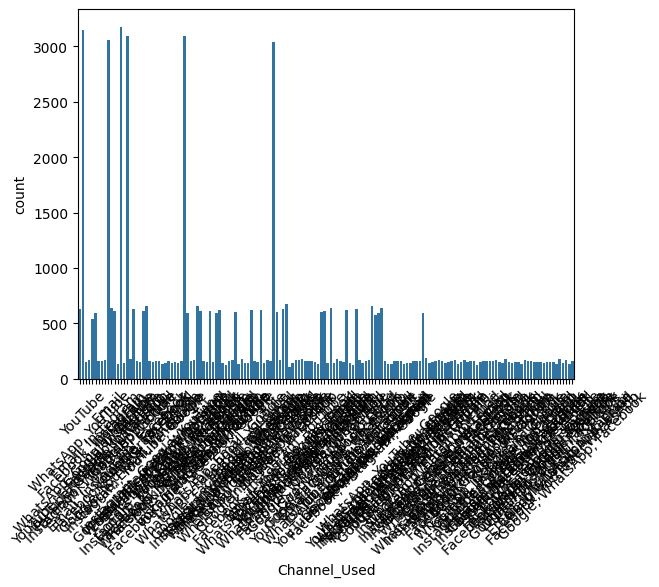

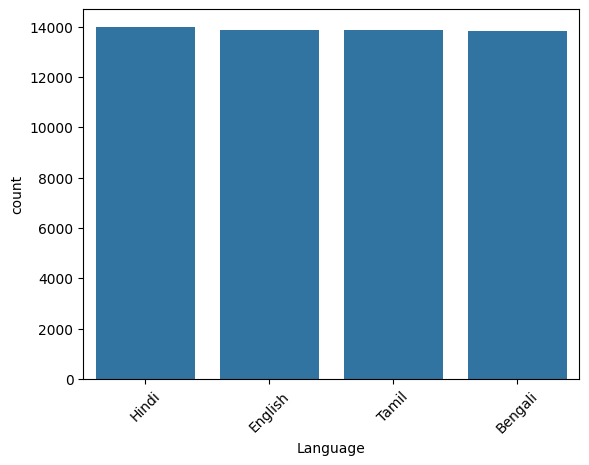

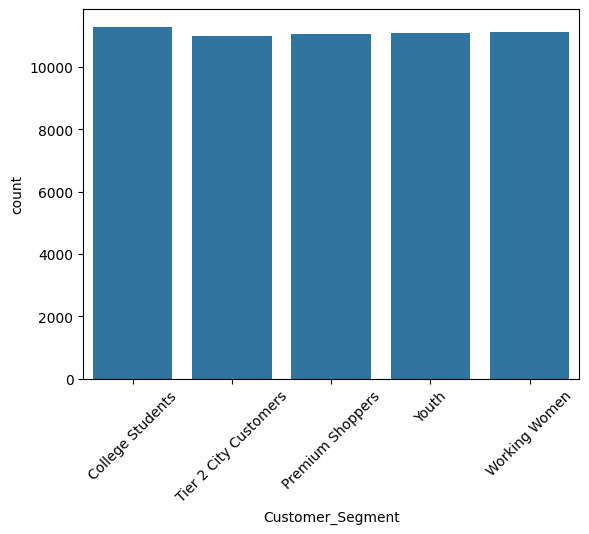

In [93]:
for col in cols_cat:
  #nykaa[col].value_counts()

  sns.countplot(x = nykaa[col], data = nykaa)
  plt.xticks(rotation=45)
  plt.show()

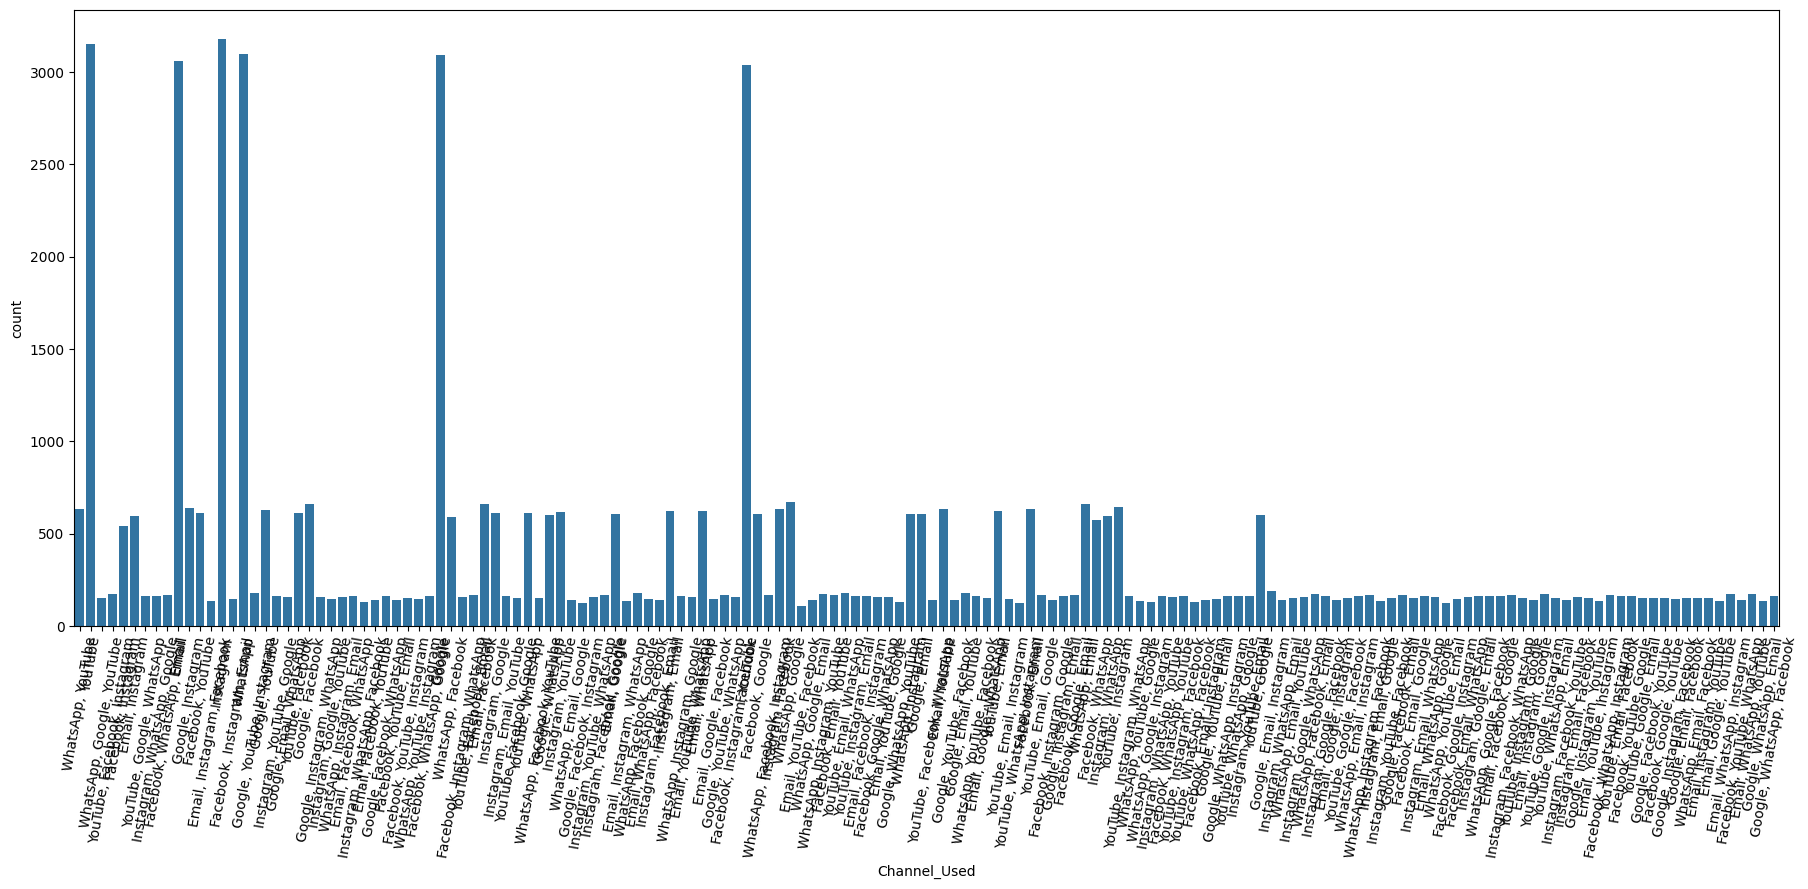

In [94]:
  plt.figure(figsize=(22,8))
  sns.countplot(x = nykaa["Channel_Used"], data = nykaa)
  plt.xticks(rotation=80)
  plt.show()

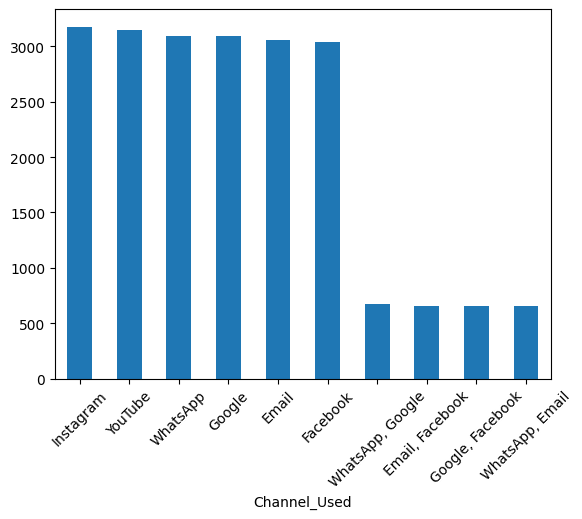

In [95]:
top = nykaa["Channel_Used"].value_counts().head(10)

top.plot(kind='bar')

plt.xticks(rotation=45)
plt.show()

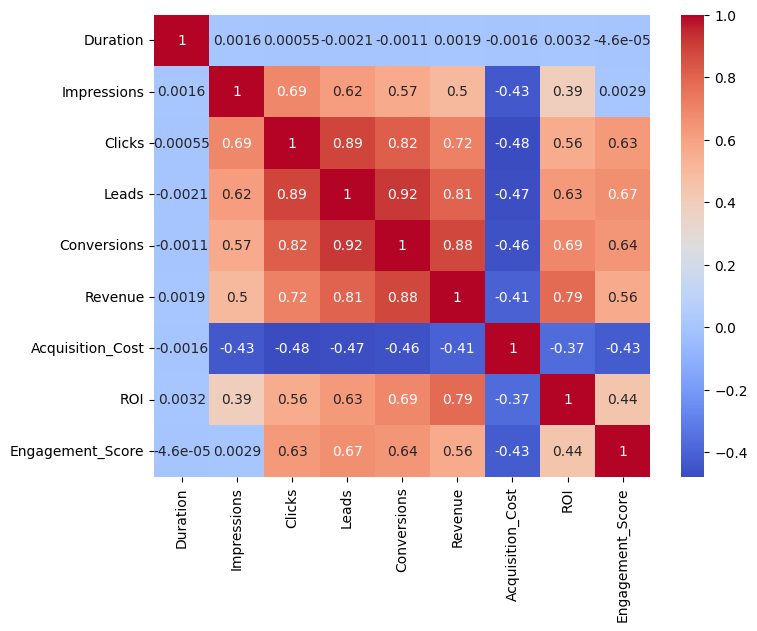

In [96]:
corr = nykaa.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

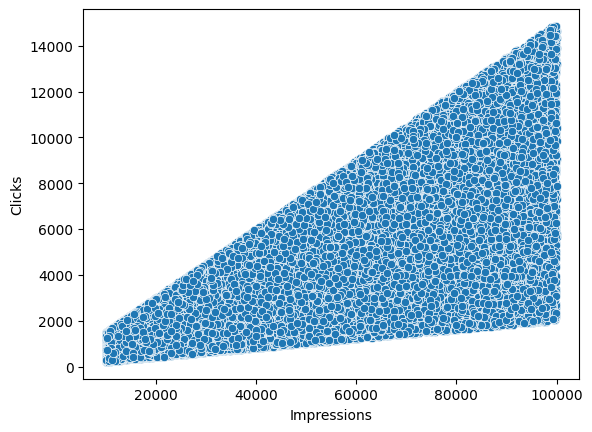

In [97]:
sns.scatterplot(x='Impressions', y='Clicks', data=nykaa)
plt.show()

In [98]:
purplle = pd.read_csv("data/purplle_campaign_data.csv")
purplle.head(10)

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,PU-CMP-1000,Paid Ads,Working Women,6,"Facebook, Google",31869,3490,1946,902,493394,55.93,8.78,Tamil,19.89,Premium Shoppers,27-12-2024
1,PU-CMP-1001,Paid Ads,Premium Shoppers,8,"Instagram, WhatsApp",26640,2441,741,314,108644,197.44,0.75,Bengali,13.12,Premium Shoppers,26-11-2024
2,PU-CMP-1002,Influencer,Youth,22,"Facebook, WhatsApp",36967,4997,1025,653,238345,234.59,0.56,English,18.06,College Students,08-01-2025
3,PU-CMP-1003,Paid Ads,Youth,15,"Instagram, WhatsApp",73258,5893,2565,1970,1341570,103.76,5.56,Bengali,14.23,College Students,14-03-2025
4,PU-CMP-1004,Social Media,Premium Shoppers,11,"WhatsApp, Instagram",91081,6393,3282,2582,787510,78.61,2.88,English,13.46,College Students,11-07-2024
5,PU-CMP-1005,SEO,Tier 2 City Customers,12,Email,18715,976,555,364,158340,411.09,0.06,Bengali,10.13,College Students,09-11-2024
6,PU-CMP-1006,SEO,Youth,10,"Google, Facebook",75752,9883,5783,4300,3427100,60.38,12.20,English,26.36,Working Women,28-07-2024
7,PU-CMP-1007,Paid Ads,College Students,12,"WhatsApp, Google",87117,5441,2231,1716,713856,42.22,8.85,Hindi,10.78,Tier 2 City Customers,26-11-2024
8,PU-CMP-1008,Paid Ads,Tier 2 City Customers,19,"Google, Email, Facebook",89807,4931,2639,2052,627912,124.35,1.46,Hindi,10.71,Tier 2 City Customers,18-08-2024
9,PU-CMP-1009,Paid Ads,College Students,18,"Instagram, Google",95629,6410,2147,1149,687102,84.20,6.10,English,10.15,Working Women,08-12-2024


In [99]:
purplle.shape # shame struct as nykaa

(55555, 16)

In [100]:
purplle.isnull().sum() # again same as nykaa

Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [101]:
cols = ["Duration", "Impressions","Clicks",	"Leads"	,"Conversions", 	"Revenue",	"Acquisition_Cost",	"ROI", "Engagement_Score"]

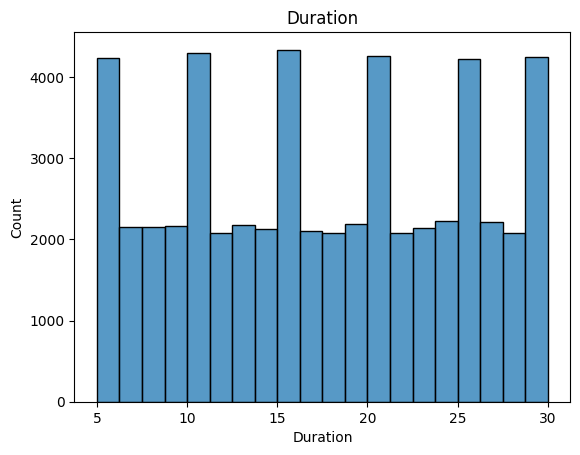

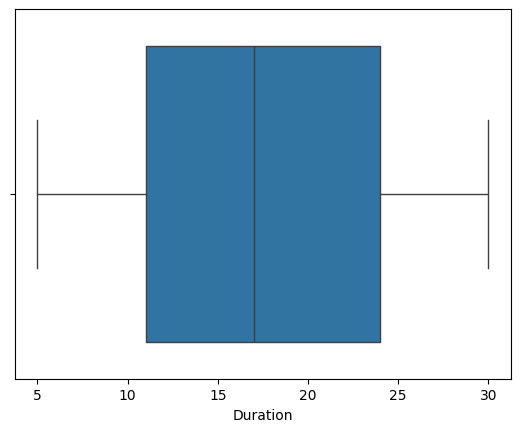

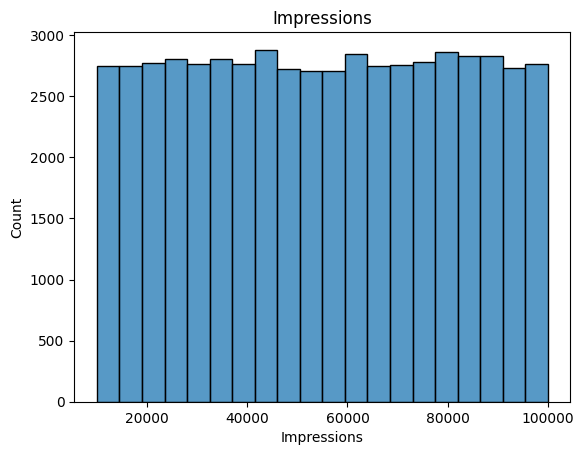

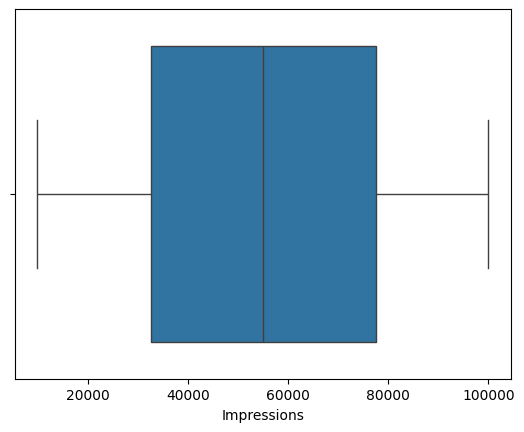

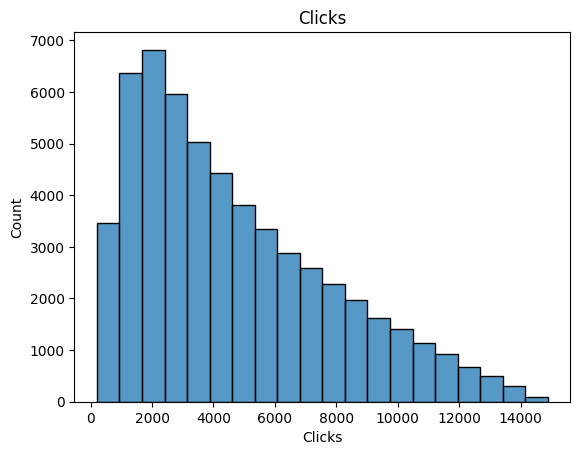

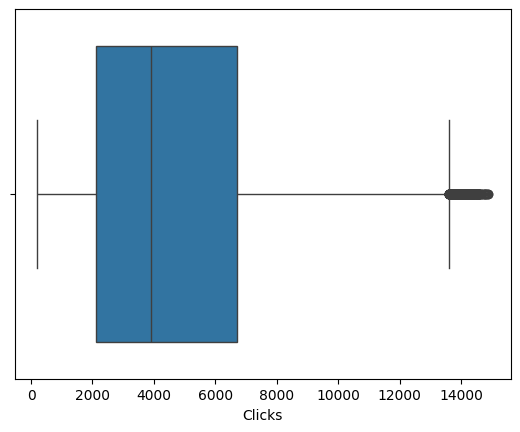

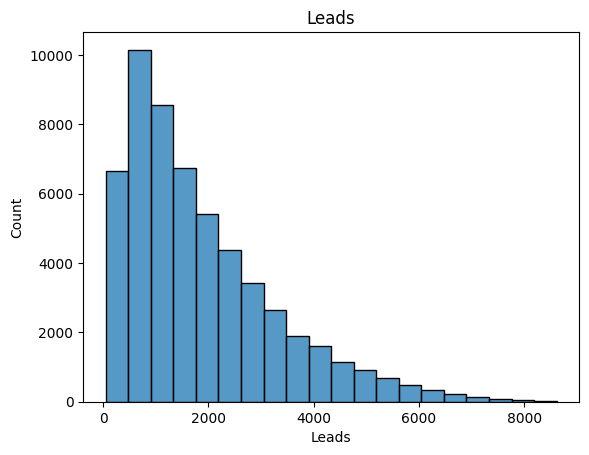

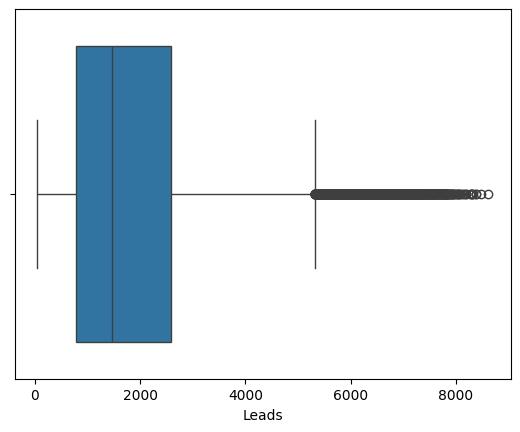

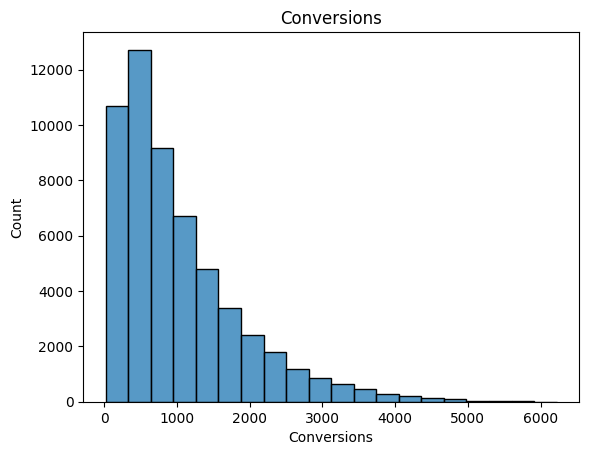

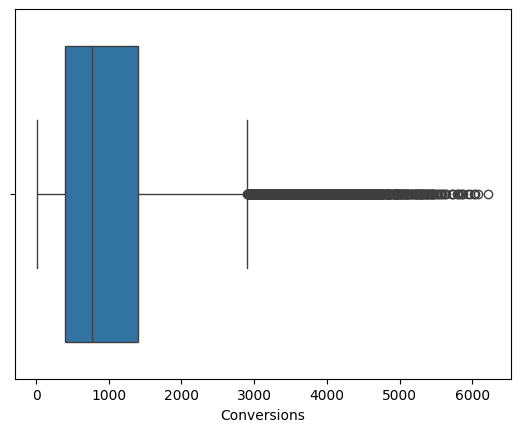

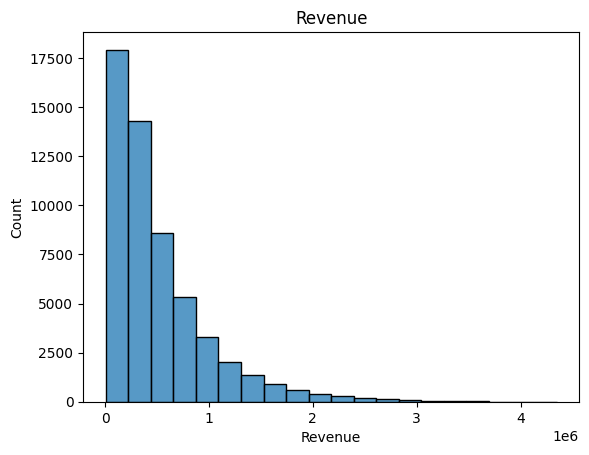

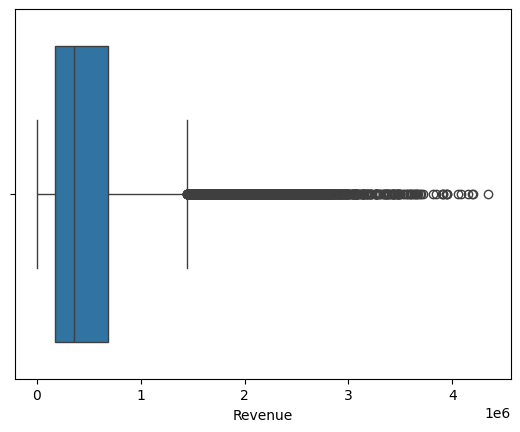

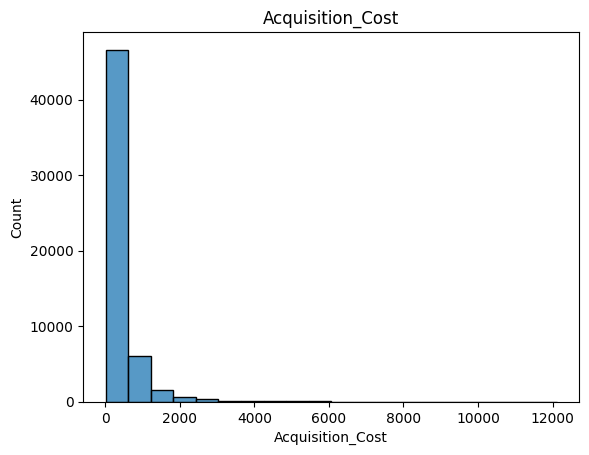

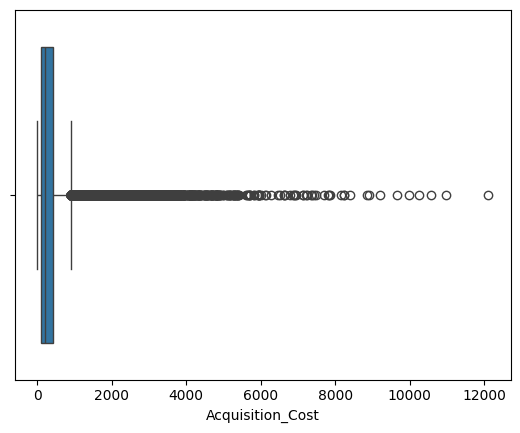

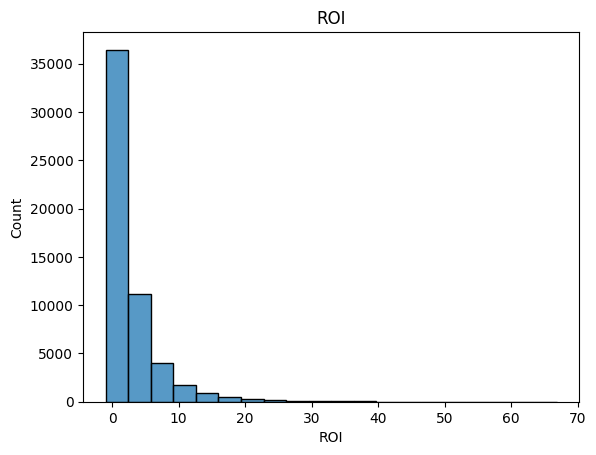

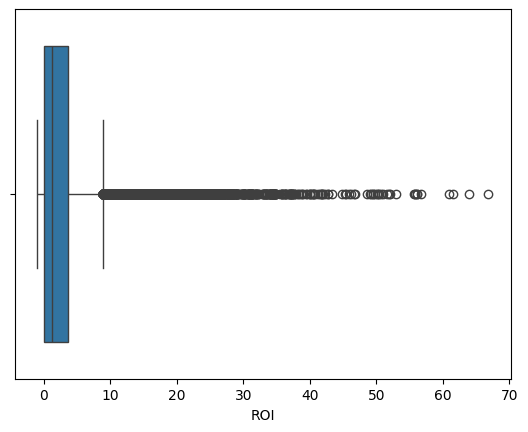

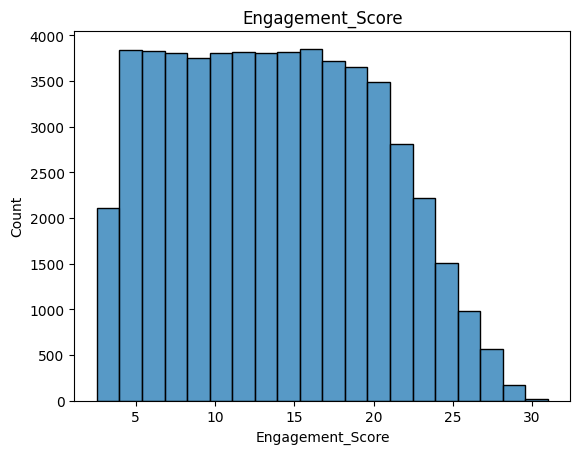

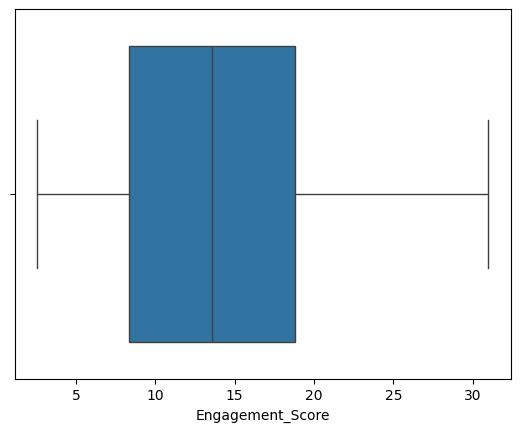

In [102]:
for col in cols:
  sns.histplot(purplle[col], bins=20)
  plt.title(col)
  plt.show()

  sns.boxplot(x = purplle[col])
  plt.show()

Text(0.5, 1.0, 'Purplle Engagement Score')

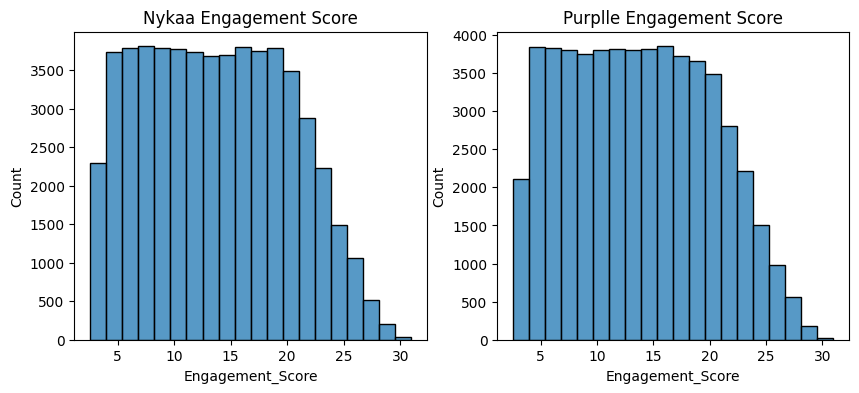

In [103]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(nykaa['Engagement_Score'], bins=20)
plt.title("Nykaa Engagement Score")

plt.subplot(1,2,2)
sns.histplot(purplle['Engagement_Score'], bins=20)
plt.title("Purplle Engagement Score")


In [104]:
cols_cat = ["Campaign_Type",	"Target_Audience", "Target_Audience",  "Language",	"Customer_Segment"]

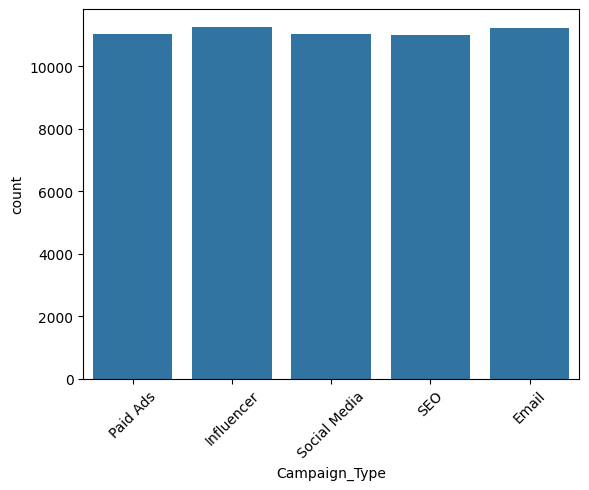

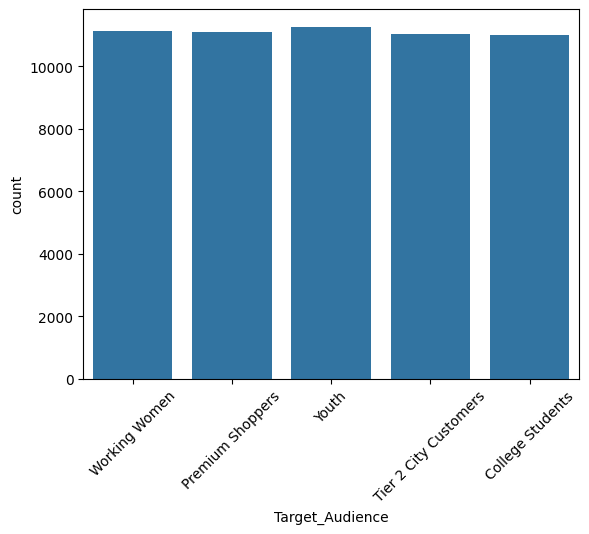

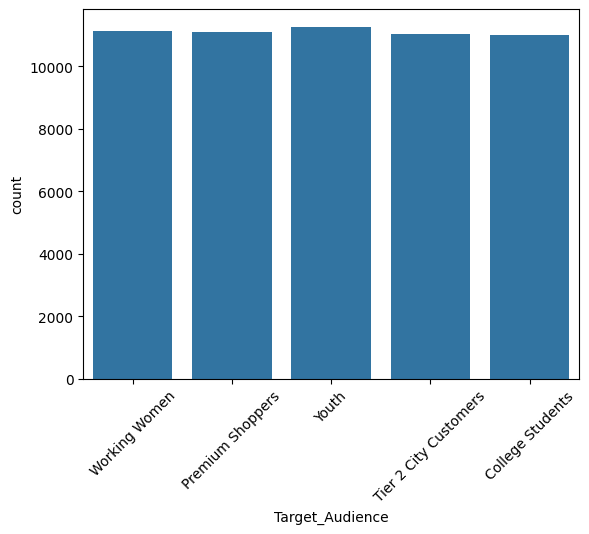

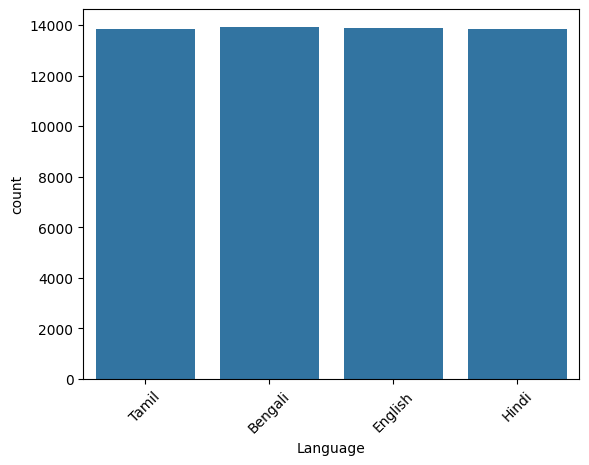

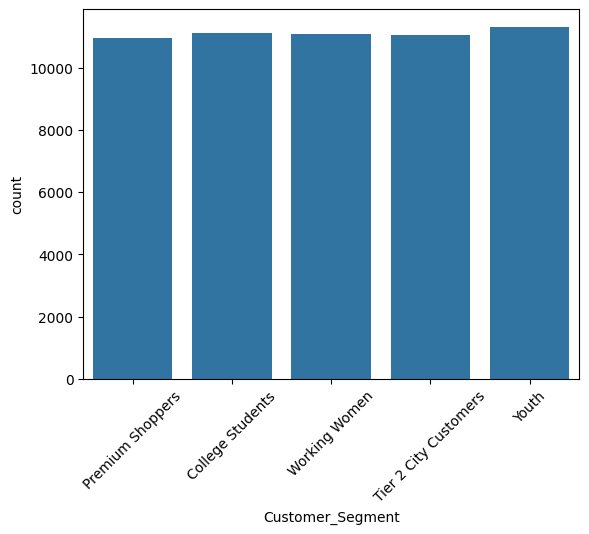

In [105]:
for col in cols_cat:

  sns.countplot(x = purplle[col], data = purplle)
  plt.xticks(rotation=45)
  plt.show()

Text(0, 0.5, 'Count')

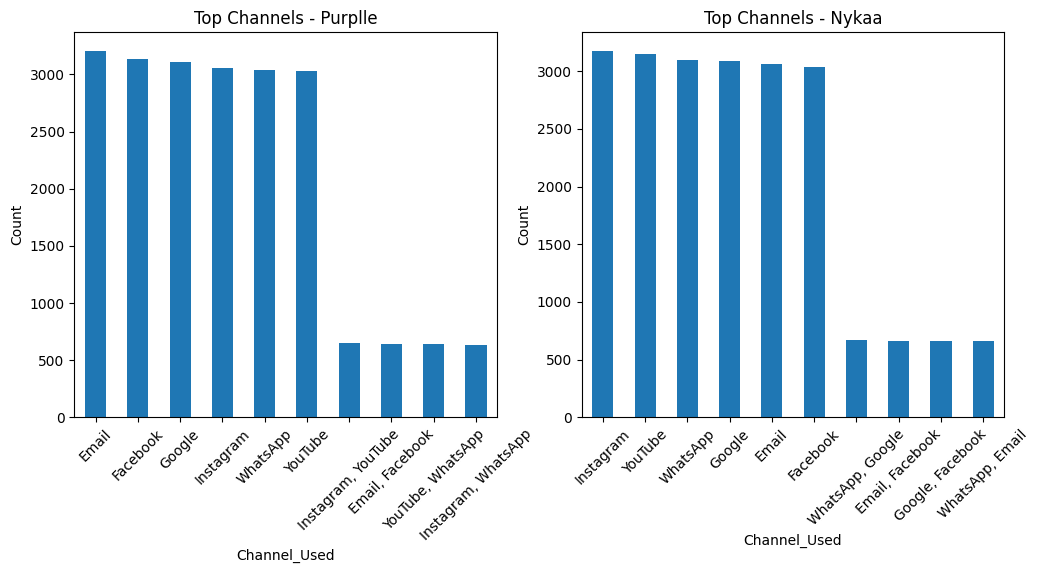

In [106]:
plt.figure(figsize=(12,5))

top_purplle = purplle["Channel_Used"].value_counts().head(10)
top_nykaa = nykaa["Channel_Used"].value_counts().head(10)
# Purplle
plt.subplot(1,2,1)
top_purplle.plot(kind='bar')
plt.title("Top Channels - Purplle")
plt.xticks(rotation=45)
plt.ylabel("Count")

# Nykaa
plt.subplot(1,2,2)
top_nykaa.plot(kind='bar')
plt.title("Top Channels - Nykaa")
plt.xticks(rotation=45)
plt.ylabel("Count")

In [107]:
tira = pd.read_csv("data/tira_campaign_data.csv")
tira.head(10)

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,TI-CMP-1000,SEO,Working Women,11,Instagram,64004,2906,1639,952,222768,129.72,0.80,Tamil,8.59,Premium Shoppers,30-10-2024
1,TI-CMP-1001,Social Media,Tier 2 City Customers,24,YouTube,71795,2051,552,256,199168,316.36,1.46,Tamil,3.98,College Students,11-09-2024
2,TI-CMP-1002,Paid Ads,Working Women,28,Instagram,79158,3546,1928,1314,433620,91.25,2.62,English,8.58,Tier 2 City Customers,28-08-2024
3,TI-CMP-1003,Email,Youth,8,Google,31523,3721,2088,736,571872,161.13,3.82,Bengali,20.76,Youth,27-07-2024
4,TI-CMP-1004,Paid Ads,Premium Shoppers,15,"Facebook, Email, WhatsApp",61441,7277,3615,2602,1477936,82.07,5.92,Tamil,21.96,College Students,19-12-2024
5,TI-CMP-1005,Email,Tier 2 City Customers,6,"Google, Facebook",32340,4722,1102,698,185668,194.21,0.37,English,20.17,Tier 2 City Customers,26-09-2024
6,TI-CMP-1006,Social Media,Working Women,5,"Email, YouTube, WhatsApp",91729,13151,5556,4153,2691144,32.98,18.65,English,24.92,Premium Shoppers,08-02-2025
7,TI-CMP-1007,Social Media,Working Women,21,"Google, Facebook, Instagram",65005,7269,3868,2118,1230558,141.08,3.12,Bengali,20.39,College Students,14-11-2024
8,TI-CMP-1008,Email,Working Women,20,YouTube,73189,8370,3960,2248,804784,43.89,7.16,Hindi,19.92,College Students,19-08-2024
9,TI-CMP-1009,Influencer,College Students,30,"Email, WhatsApp, Facebook",45172,5934,2313,1432,890704,190.58,2.26,English,21.43,Youth,13-10-2024


In [108]:
nykaa['platform'] = "Nykaa"
purplle['platform'] = "Purplle"
tira['platform'] = "Tira"

df = pd.concat([nykaa, purplle, tira])

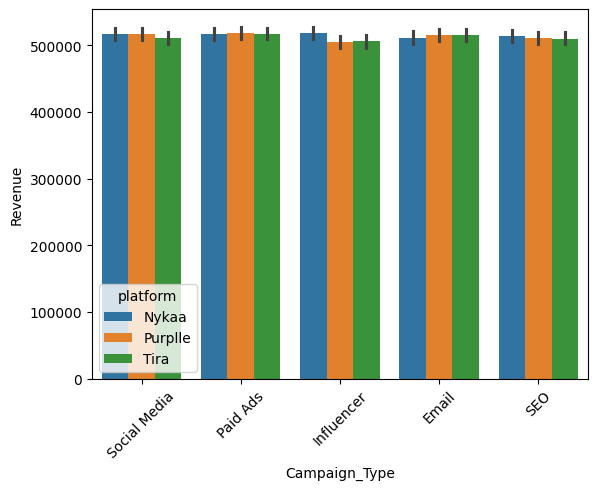

In [109]:
sns.barplot(x='Campaign_Type', y='Revenue', hue='platform', data=df)

plt.xticks(rotation=45)
plt.show()

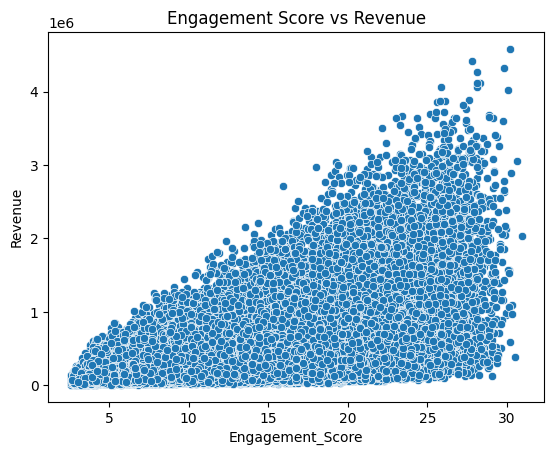

In [110]:
sns.scatterplot(x='Engagement_Score', y='Revenue', data=nykaa)

plt.title("Engagement Score vs Revenue")
plt.show()

<Axes: xlabel='Engagement_Score', ylabel='Revenue'>

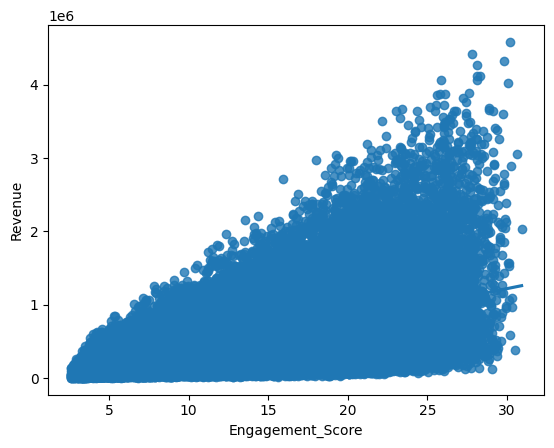

In [111]:
sns.regplot(x='Engagement_Score', y='Revenue', data=nykaa)


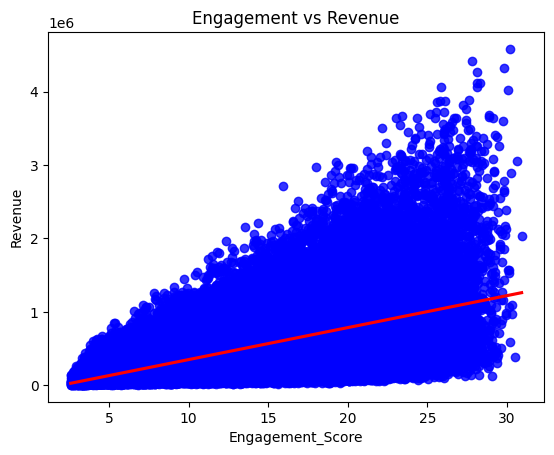

In [112]:
sns.regplot(
    x='Engagement_Score',
    y='Revenue',
    data=nykaa,
    scatter_kws={'color': 'blue'},
    line_kws={'color': 'red'}
)
plt.title("Engagement vs Revenue")
plt.show()

Maybe I can explore what marketing strategies generate the most engagement and revenue, and how can we optimize campaigns to perform better. Since "Channel_Used" variable sometimes contains multiple marketing channels separated by commas, I will add other variables like "Instagram_used",.. etc. to enable more precise analysis